# U-Net testing

In [1]:
!hostname

mtx37


In [2]:
import glob
import os
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, UpSampling2D, Conv2DTranspose, Reshape, concatenate, Dropout, Rescaling, LeakyReLU
import tensorflow.keras.layers as L
from tensorflow.keras.models import Model
from astropy.io import fits
import matplotlib.pyplot as plt
from gelsa import visu
from tqdm.notebook import tqdm
import tensorflow.keras.backend as K

2025-12-02 22:34:34.134389: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 22:34:34.191059: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-02 22:34:34.191083: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-02 22:34:34.191090: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-02 22:34:34.197493: I tensorflow/core/platform/cpu_feature_g

### Selecting GPU (0-4), if available

In [3]:
gpu=2
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.set_visible_devices(gpus[gpu], 'GPU')
    logical_gpus = tf.config.list_logical_devices('GPU')
    print("Using GPU number {}".format(gpu))
  except RuntimeError as e:
    print(e)
else:
    print("GPU not found")

GPU not found


In [4]:
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TF version: 2.14.0
Built with CUDA: True
GPU devices: []


### Importing the data

In [5]:
hdu_rect = fits.open("/scratch/astro/nicolo.fiaba/training_sets_EL/labels_RGS000_minus4.fits", memmap=True)
hdu_rect_masked = fits.open("/scratch/astro/nicolo.fiaba/training_sets_EL/train_RGS000_minus4.fits", memmap=True)

In [6]:
img_data = np.array([hdu.data for hdu in hdu_rect[1:]])
img_data_masked = np.array([hdu.data for hdu in hdu_rect_masked[1:]])

In [7]:
""" Mask object: 
- 0: Existing pixel
- 1: Missing pixel
"""
mask = np.isnan(img_data_masked).astype(np.float32)

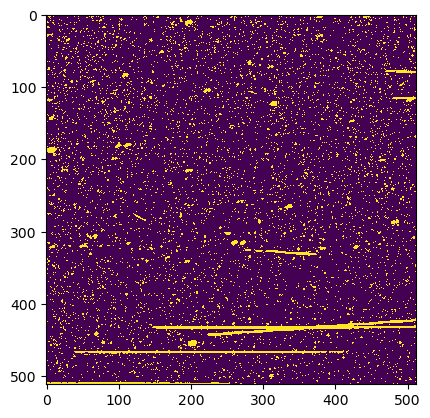

In [8]:
plt.imshow(mask[32], interpolation='nearest')

### Setting a threshold to the flux value in each pixel:
> Whenever a pixel exceeds the flux value of **16000**, its value is set back to **16000**

In [9]:
max_threshold = 16000 
"""
This was suggested by Savio. 
Ask again why, because looking at real data this doesn't seem to be the pixels maximum value. Anyway..
"""
img_data[img_data > max_threshold] = max_threshold
img_data_masked[img_data_masked > max_threshold] = max_threshold

In [10]:
m = img_data <= img_data.mean()
print(np.sum(m[0]==True), "pixels are below average flux")
print(np.sum(m[0]==False), "pixels are above average flux")

252117 pixels are below average flux
10027 pixels are above average flux


### Add gaussian noise to the spectra ($\sigma = \sqrt{800}$)

In [11]:
# Noise
sigma = np.sqrt(800)
size = (len(img_data), 512, 512)
noise = np.random.normal(loc=0, scale=sigma, size=size)

In [12]:
img_noise = img_data #+ noise (No noise on labels)
img_noise_masked = img_data_masked + noise

img_noise = np.array(img_noise, dtype=np.float32)
img_noise_masked = np.array(img_noise_masked, dtype=np.float32)

### Rescaling images

In ML it's crucial to renormalize the data in the (0, 1) range or (-1, 1). 

Everything is **rescaled** with the **same factor**, the maximum flux is the images with emission lines (since they are the brightest).

**NB**: The mask dataset is already normalized [0, 1]

In [13]:
# Image normalization -> (0,1)
x_max = np.nanmax(img_noise)
x_min = np.nanmin(img_noise)
rescale = Rescaling(1./(x_max - x_min), offset=-x_min/(x_max - x_min), input_shape=(512, 512, 1))

In [14]:
img_noise = rescale(img_noise)
img_noise_masked = rescale(img_noise_masked)

# Converting to numpy, otherwise train_test_split function won't work
img_noise = img_noise.numpy()
img_noise_masked = img_noise_masked.numpy()

#### We stack the **masked images** and the **masks** themselves: 
These will be the inputs of the network: $(512, 512, 2)$

In [15]:
input_imgs = np.stack([img_noise_masked, mask], axis=-1)

### Train and test set split

In [16]:
# test set is 10% of the whole dataset
x_train, x_test, y_train, y_test = train_test_split(
    input_imgs, img_noise, test_size=0.1, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42)

x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
x_val = tf.convert_to_tensor(x_val, dtype=tf.float32)
x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)

y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

In [17]:
# Set NaNs to 0 before feeding the U-Net
# NaNs are ONLY in the training images, not labels
x_train = tf.where(tf.math.is_nan(x_train), 0., x_train)
x_val = tf.where(tf.math.is_nan(x_val), 0., x_val)
x_test = tf.where(tf.math.is_nan(x_test), 0., x_test)

image_size = (x_train.shape[1], x_train.shape[2])

#### Now the lists are:

- `x_train`, `x_test`, `x_val` : training, test and validation sets 
- `y_train`,`y_test`,`y_val` : training, test and validation sets of labels

In [18]:
print("Images in training set:", len(x_train),
      "\nImages in validation set:", len(x_val),
      "\nImages in test set:", len(x_test),
      "\nImage size:", image_size)

Images in training set: 3386 
Images in validation set: 847 
Images in test set: 471 
Image size: (512, 512)


In [19]:
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices((x_train[:], y_train[:])).batch(BATCH_SIZE)#.shuffle(100)
val_dataset = tf.data.Dataset.from_tensor_slices((x_val[:], y_val[:])).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test[:], y_test[:])).batch(BATCH_SIZE)

In [20]:
x_train.shape

TensorShape([3386, 512, 512, 2])

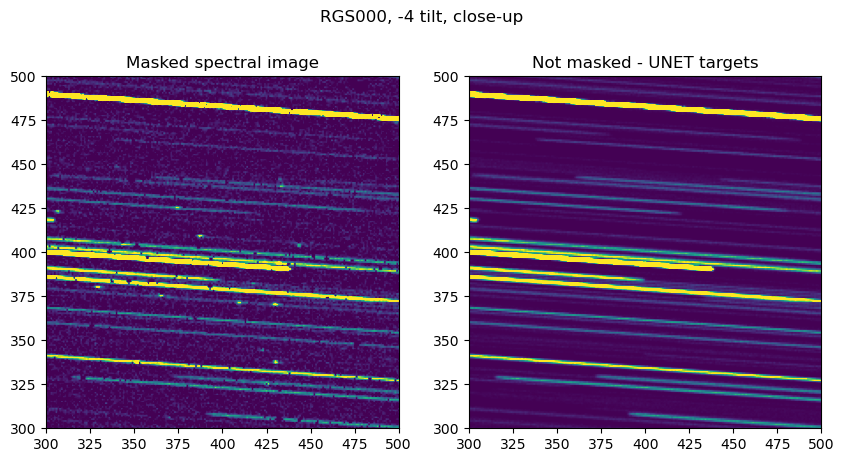

In [30]:
xlow, xhigh = 300, 500
ylow, yhigh = 300, 500

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
index = 456
plt.suptitle("RGS000, -4 tilt, close-up")
plt.subplot(121)
plt.xlim(xlow, xhigh)
plt.ylim(ylow, yhigh)
plt.imshow(x_train[index][...,0], origin='lower', aspect=1, vmin=0, vmax=0.03)
plt.title("Masked spectral image")

plt.subplot(122)
plt.imshow(y_train[index], origin='lower', aspect=1, vmin=0, vmax=0.03)
plt.xlim(xlow, xhigh)
plt.ylim(ylow, yhigh)
plt.title("Not masked - UNET targets")
# plt.savefig("EL_train_labels.png")

In [24]:
# w can easily become an hyperparameter to be optimized
def weighted_L2_loss(w):
    def loss(y_true, y_pred):
        error = K.square(y_true - y_pred)
        error = K.switch(K.less(y_true, tf.reduce_mean(train)), w * error, error)
        return error 
    return loss

def pow_downweight_loss(alpha):
    def loss(y_true, y_pred):
        y_true_clipped = K.clip(y_true, K.epsilon(), 1.0)
        y_pred_clipped = K.clip(y_pred, K.epsilon(), 1.0)

        y_true_rescaled = K.pow(y_true_clipped, alpha)
        y_pred_rescaled = K.pow(y_pred_clipped, alpha)

        error = K.square(y_true_rescaled - y_pred_rescaled)
        return error
    return K.mean(loss)

def log_downweight_loss(y_true, y_pred):
    
    y_true_rescaled = tf.math.log(1 + y_true)
    y_pred_rescaled = tf.math.log(1 + y_pred)

    error = K.square(y_true_rescaled - y_pred_rescaled)
    return K.mean(error)

def get_gradients(img):
    # img: (batch, H, W, 1)
    if len(img.shape) == 3:
        img = tf.expand_dims(img, axis=-1)  # add channel
    # horizontal gradient (dx)
    gx = tf.image.sobel_edges(img)[..., 0]
    # vertical gradient (dy)
    gy = tf.image.sobel_edges(img)[..., 1]

    return gx, gy

def gradient_loss(y_true, y_pred):
    gx_true, gy_true = get_gradients(y_true)
    gx_pred, gy_pred = get_gradients(y_pred)

    loss_gx = tf.reduce_mean(tf.abs(gx_true - gx_pred))
    loss_gy = tf.reduce_mean(tf.abs(gy_true - gy_pred))

    return loss_gx + loss_gy

def total_gradient_loss(y_true, y_pred):
    l1 = tf.reduce_mean(tf.abs(y_true - y_pred))
    g = gradient_loss(y_true, y_pred)

    return l1 + 0.2 * g 

def ssim_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # safety: ensure channel dimension is present
    if len(y_true.shape) == 3:
        y_true = tf.expand_dims(y_true, -1)
    if len(y_pred.shape) == 3:
        y_pred = tf.expand_dims(y_pred, -1)

    # compute 1 - SSIM
    return 1 - tf.image.ssim(
        y_true, y_pred,
        max_val=1.0,        # dynamic range
        filter_size=11      # your kernel size
    )

In [25]:
# Set hyerparameters
EPOCHS = 300
LEARNING_RATE = 1e-3
INIT_LR = 1e-3
MAX_LR = 1

### Define the Neural Network

Architecture: [Image Inpainting Using AutoEncoder and Guided Selection of Predicted Pixels by Mohammad H. Givkashi](https://arxiv.org/pdf/2112.09262)

In [26]:
# Model 2: U-Net (usually used for Image Segmentation of Biomedical images)
# Define construction functions for fundamental blocks

def double_conv_block(x, n_filters):

    x = Conv2D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Conv2D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
    x = LeakyReLU(alpha=0.1)(x)

    return x

def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = MaxPool2D(2)(f)
    # p = Dropout(0.3)(p)
    return f, p

def upsample_block(x, conv_features, n_filters):
    # 3: kernel size
    # 2: strides
    x = Conv2DTranspose(n_filters, 3, 2, padding='same')(x)
    x = concatenate([x, conv_features])
    # x = Dropout(0.3)(x)
    x = double_conv_block(x, n_filters)
    return x

In [27]:
# Define blocks for the Attention U-Net architecture (U-Net + Attention gates)

def conv_block(x, num_filters):
    x = L.Conv2D(num_filters, 3, padding='same')(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    x = L.Conv2D(num_filters, 3, padding='same')(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    return x

def encoder_block(x, num_filters):
    x = conv_block(x, num_filters)
    p = L.MaxPool2D((2,2))(x)
    return x, p

def attention_gate(g, s, num_filters):
    Wg = L.Conv2D(num_filters, 1, padding='same')(g)
    Wg = L.BatchNormalization()(Wg)

    Ws = L.Conv2D(num_filters, 1, padding='same')(s)
    Ws = L.BatchNormalization()(Ws)

    out = L.Activation("relu")(Wg + Ws)
    out = L.Conv2D(num_filters, 1, padding='same')(out)
    out = L.Activation('sigmoid')(out)

    return out * s

def decoder_block(x, s, num_filters):
    x = L.UpSampling2D(interpolation='bilinear')(x)
    s = attention_gate(x, s, num_filters)
    x = L.Concatenate()([x, s])
    x = conv_block(x, num_filters)
    return x

In [28]:
# Build the U-Net model

def make_unet_model(image_size):
    inputs = Input(shape=(image_size[0], image_size[1], 1))

    # Encoder
    f1, p1 = downsample_block(inputs, 64)
    f2, p2 = downsample_block(p1, 128)
    f3, p3 = downsample_block(p2, 256)
    f4, p4 = downsample_block(p3, 512)
    
    # Bottleneck
    bottleneck = double_conv_block(p4, 1024)
    
    # Decoder
    u6 = upsample_block(bottleneck, f4, 512)
    u7 = upsample_block(u6, f3, 256)
    u8 = upsample_block(u7, f2, 128)
    u9 = upsample_block(u8, f1, 64)

    # Output
    outputs = Conv2D(1, 1, padding='same', activation='sigmoid')(u9)

    unet_model = Model(inputs, outputs, name='U-Net')

    return unet_model

# -----------------------------------------------------------------------

def attention_unet(image_size):
    """ Inputs """
    inputs = L.Input(shape=(image_size[0], image_size[1], 1))

    """ Encoder """
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    """ Bridge / Bottleneck """
    b1 = conv_block(p4, 1024)

    """ Decoder """
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    """ Outputs """
    outputs = L.Conv2D(1, 1, padding='same', activation='sigmoid')(d4)

    attention_unet_model = Model(inputs, outputs, name='Attention-UNET')
    return attention_unet_model

In [29]:
"""
unet_model = make_unet_model(image_size)

unet_model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate = 1),
                  # optimizer=optimizer,
                  loss='mse',
                  metrics=['mse'])

# unet_model.summary()
"""

"\nunet_model = make_unet_model(image_size)\n\nunet_model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate = 1),\n                  # optimizer=optimizer,\n                  loss='mse',\n                  metrics=['mse'])\n\n# unet_model.summary()\n"

In [30]:
attention_unet_model = attention_unet(image_size)

attention_unet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-3),
                  # optimizer=optimizer,
                  loss=total_gradient_loss,
                  metrics=['mae'])

# attention_unet_model.summary()

In [31]:
import os
checkpoint_path = "/scratch/astro/nicolo.fiaba/training_weights/unet_ckp.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 monitor='val_loss',
                                                 save_best_only=True,
                                                 save_weights_only=True,
                                                 verbose=1)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=3,
                                           restore_best_weights=True,
                                           start_from_epoch=100)

def lr_schedule(epoch):
    if epoch < 295:
        return 1e-2
    elif epoch < 500:
        return 1e-3
    else:
        return 1e-5

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

### Defining hyperparameters

In [32]:
print("Running for", EPOCHS, "epochs")

Running for 300 epochs


### Training on GPU (`gpu03`)

In [70]:
hist = attention_unet_model.fit(
    train_dataset,
    epochs=EPOCHS,
    #batch_size=BATCH_SIZE,
    # shuffle=True,
    validation_data=val_dataset,
    callbacks=[lr_callback],
    verbose=2
)

Epoch 1/300
1/1 - 8s - loss: 0.4507 - mae: 0.4507 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 8s/epoch - 8s/step
Epoch 2/300
1/1 - 2s - loss: 0.2614 - mae: 0.2614 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 2s/epoch - 2s/step
Epoch 3/300
1/1 - 2s - loss: 0.1918 - mae: 0.1918 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 2s/epoch - 2s/step
Epoch 4/300
1/1 - 1s - loss: 0.1628 - mae: 0.1628 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 1s/epoch - 1s/step
Epoch 5/300
1/1 - 2s - loss: 0.1323 - mae: 0.1323 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 2s/epoch - 2s/step
Epoch 6/300
1/1 - 2s - loss: 0.1063 - mae: 0.1063 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 2s/epoch - 2s/step
Epoch 7/300
1/1 - 1s - loss: 0.0883 - mae: 0.0883 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 1s/epoch - 1s/step
Epoch 8/300
1/1 - 2s - loss: 0.0730 - mae: 0.0730 - val_loss: 0.9810 - val_mae: 0.9810 - lr: 0.0100 - 2s/epoch - 2s/step
Epoch 9/300
1/1 - 2s - loss: 0.0

In [43]:
plt.plot(hist.history['loss'], label='Loss')
plt.plot(hist.history['val_loss'], label='Validation loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.2)
plt.legend()
# plt.savefig("training_loss.png")

NameError: name 'hist' is not defined

In [42]:
# attention_unet_model.save("/scratch/astro/nicolo.fiaba/trained_models/attention_unet_test.h5")

#### Saving the learning history

In [74]:
"""
import pickle
with open('/home/PERSONALE/nicolo.fiaba/trainHistoryDict', 'wb') as file_pi:
    pickle.dump(hist.history, file_pi)
"""

#### Loading the learning history

In [33]:
import pickle
with open('/scratch/astro/nicolo.fiaba/trained_models/denoise_ATT_UNET_hist_RGS000_minus4', "rb") as file_pi:
    history = pickle.load(file_pi)

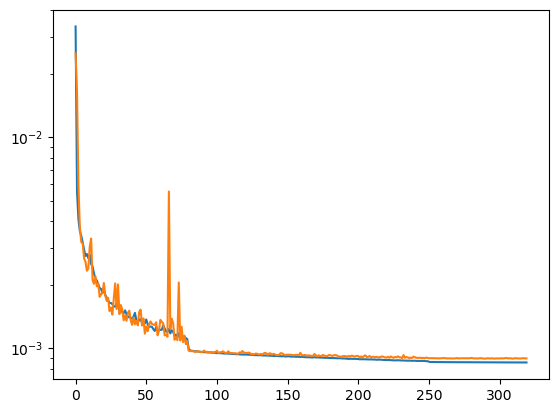

In [34]:
plt.plot(history['loss'][0:])
plt.plot(history['val_loss'][0:])
plt.yscale('log')

### Loading trained model and evaluation

In [35]:
from keras.models import load_model
saved_model = load_model('/scratch/astro/nicolo.fiaba/trained_models/denoise_attention_unet_model_RGS000_minus4.h5', compile=False)

saved_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss=total_gradient_loss,
                  metrics="mse")
# saved_model.summary()

---

In [36]:

pred_trained = saved_model.predict(test_dataset)
pred_trained = np.squeeze(pred_trained)


2025-11-28 10:19:40.165729: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2025-11-28 10:19:40.680552: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


30/30 [==============================] - 24s 404ms/step


In [74]:
"""
pred = attention_unet_model.predict(train_dataset)
pred = np.squeeze(pred)
"""

1/1 [==============================] - 1s 753ms/step


9


Text(0.5, 0.98, 'Attention gate U-Net model - Test on RGS000, -4 tilt')

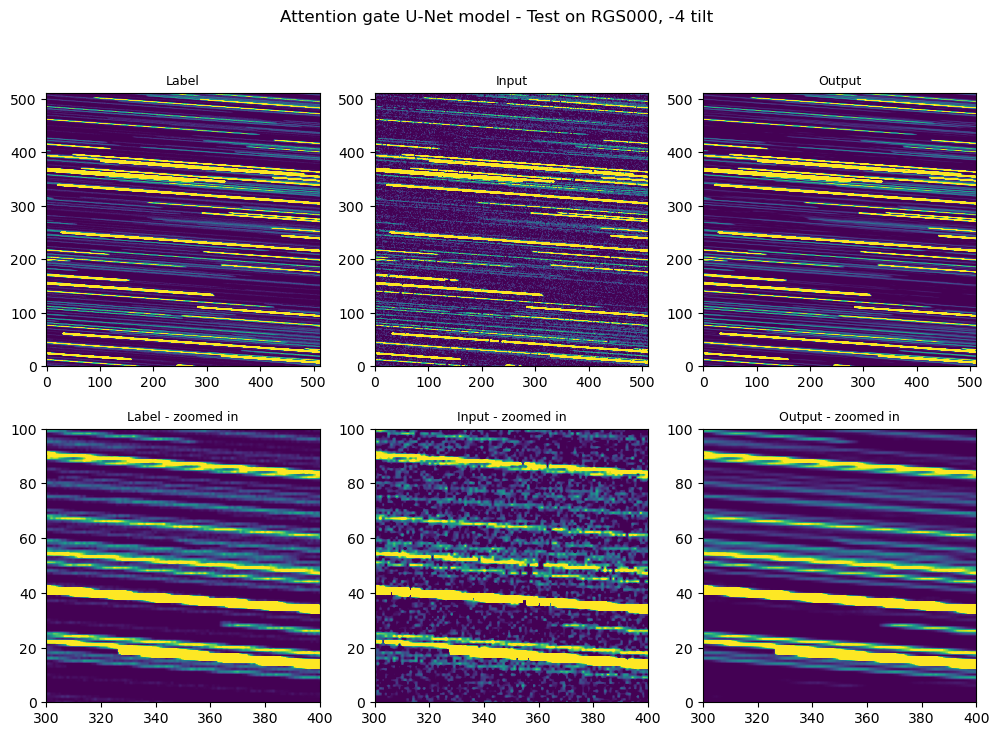

In [37]:
import random
index = 9
print(index)
from matplotlib.colors import ListedColormap

cmap = plt.cm.viridis
colors = cmap(np.arange(cmap.N))

colors[0] = [1, 1, 1, 1]

new_cmap = ListedColormap(colors)

fig, axs = plt.subplots(2, 3, figsize=(12,8))
# lis = [y_train[:10], pred]
lis = [y_test, x_test[...,0], pred_trained]
titles = ['Label', 'Input', 'Output']

for i, ax in enumerate(axs.flatten()[:3]):
    ax.imshow(lis[i][index], aspect=1, vmin=0, vmax=0.01, origin='lower')
    ax.set_title(titles[i], fontsize=9)
    # ax.set_xlim(300, 400)
    # ax.set_ylim(170, 230)
for i, ax in enumerate(axs.flatten()[3:]):
    ax.imshow(lis[i][index], aspect=1, vmin=0, vmax=0.01, origin='lower')
    ax.set_title(titles[i]+' - zoomed in', fontsize=9)
    ax.set_xlim(300, 400)
    ax.set_ylim(0, 100)
plt.suptitle("Attention gate U-Net model - Test on RGS000, -4 tilt")
# plt.savefig("denoise_attUNET_testpred.png")

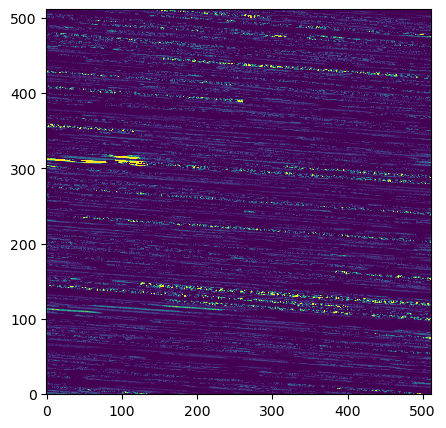

In [42]:
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(y_test[index] - pred_trained[index], aspect=1, vmin=0, vmax=0.003, origin='lower')
# ax.set_xlim(300, 400)
# ax.set_ylim(170, 230)

In [55]:
flatten_diff = tf.reshape(y_test[...,0][index]-pred_trained[index], [-1])

(-0.025, 0.025)

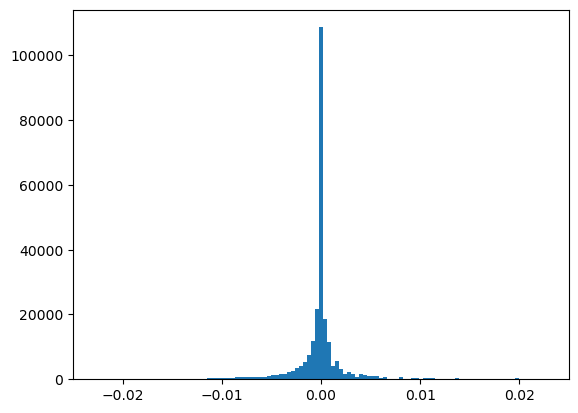

In [56]:
plt.hist(flatten_diff, bins=np.linspace(-0.02, 0.02, 100));
plt.xlim(-0.025, 0.025)

#### Reconstruction error (*mse*)

Let's compute the reconstruction error for each reconstructed image

In [48]:
indices = np.arange(len(img_data))
train_idx, test_idx = train_test_split(indices, test_size=0.1, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, random_state=42)

clean_train = img_data[train_idx]
clean_val = img_data[val_idx]
clean_test = img_data[test_idx]

clean_train = rescale(clean_train)
clean_val = rescale(clean_val)
clean_test = rescale(clean_test)

In [49]:
computed_mse = tf.reduce_mean(tf.keras.losses.MSE(test, pred_trained)).numpy()
expected_mse = tf.reduce_mean(tf.keras.losses.MSE(test, clean_test)).numpy()

print('Computed MSE:', computed_mse, "\nExpected MSE:", expected_mse)

Computed MSE: 4.98895e-05 
Expected MSE: 0.00029642938


45


Text(0.5, 0.98, 'Index: 45')

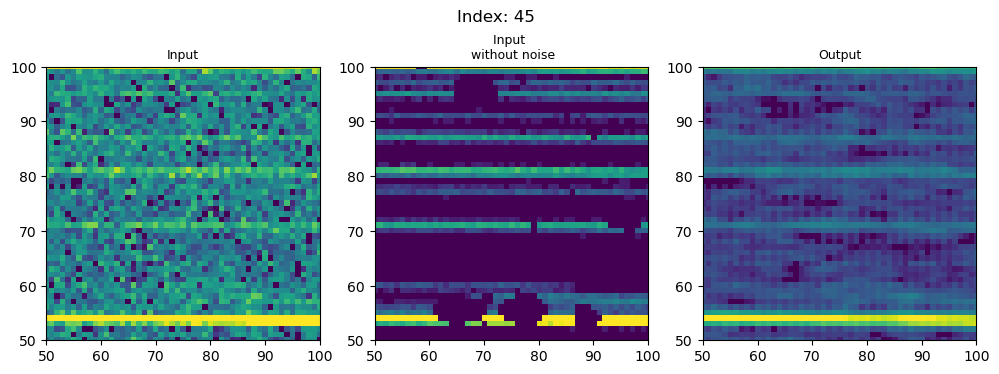

In [51]:
index = 45
print(index)

fig, axs = plt.subplots(1, 3, figsize=(12,4))
lis = [test, clean_test, pred_trained]
titles = ['Input', 'Input \n without noise', 'Output']

for i, ax in enumerate(axs.flatten()):
    ax.imshow(visu.normalize_image(lis[i][index], levels=(5, 95)), aspect=1)
    ax.set_title(titles[i], fontsize=9)
    ax.set_xlim(50, 100)
    ax.set_ylim(50, 100)
plt.suptitle("Index: {}".format(index))